In [ ]:
import polars as pl
import pandas as pd
import geopandas as gpd
import os
from shapely import wkt

In [4]:
import polars as pl
import geopandas as gpd
import glob

# 1. Recupera la lista di tutti i percorsi dei file CSV
df = pl.scan_csv("../dati_fabio/*.csv").collect()

# 3. Converti in Pandas
pdf = df.to_pandas()

# 4. Crea il GeoDataFrame
# Assicurati che 'WKT' sia scritto esattamente così nel CSV (case-sensitive)
gdf = gpd.GeoDataFrame(
    pdf, geometry=gpd.GeoSeries.from_wkt(pdf["WKT"]), crs="EPSG:4326"
)

# Opzionale: controlla le prime righe
print(gdf.head())

                               WKT     name description  \
0  POINT (167.7125182 -13.6577089)    Volow         NaN   
1  POINT (167.6390471 -13.6977393)  Mwotlap         NaN   
2  POINT (167.6884856 -13.8344582)     Mota         NaN   
3  POINT (167.5154509 -13.9011213)   Mwesen         NaN   
4                              NaN      NaN         NaN   

                      geometry  
0  POINT (167.71252 -13.65771)  
1  POINT (167.63905 -13.69774)  
2  POINT (167.68849 -13.83446)  
3  POINT (167.51545 -13.90112)  
4                         None  


In [ ]:
world = gpd.read_file(
    "C:\\Users\\SILVIA\\Documents\\progetto Fabio\\dati_fabio\\ne_110m_admin_0_countries.shp"
)

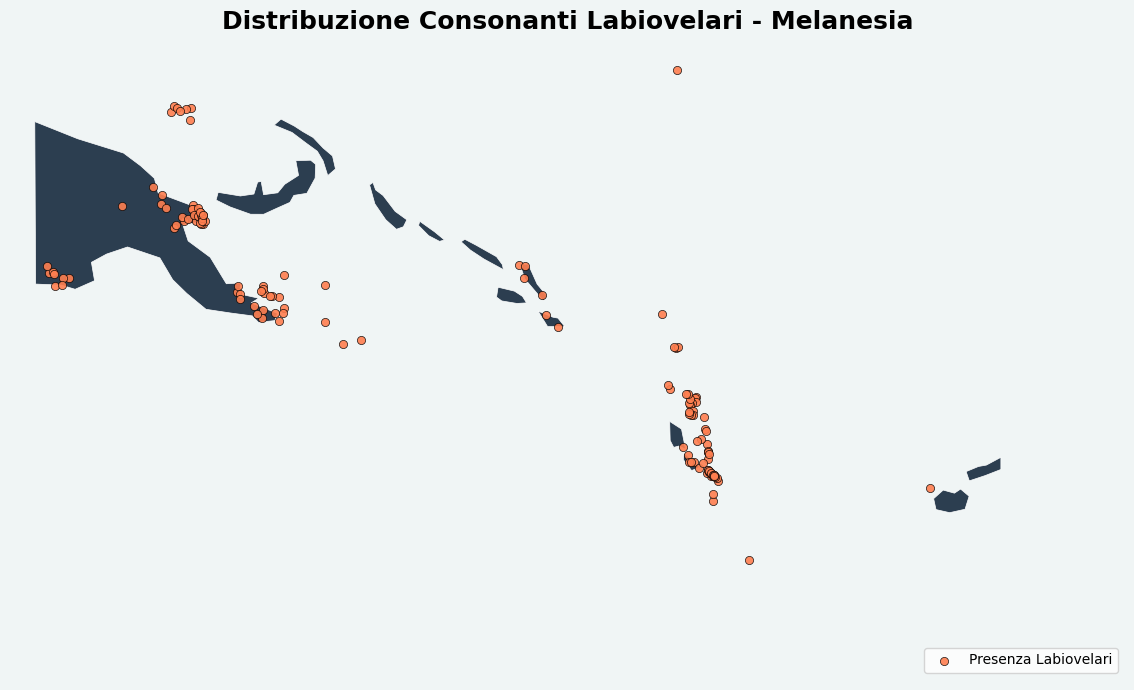

In [ ]:
# 1. Filtriamo il GDF per tenere solo i punti nell'area della Melanesia
# La Melanesia sta circa tra 140 e 185 di longitudine
gdf_filtered = gdf_clean[gdf_clean.geometry.x > 100]

# 2. Creazione della mappa migliorata
fig, ax = plt.subplots(figsize=(15, 7), facecolor="#f0f5f5")

# Disegniamo i paesi con un colore più gradevole
melanesia_base.plot(ax=ax, color="#2c3e50", edgecolor="white", linewidth=0.5)

# Disegniamo i punti con un colore che stacca (es. arancione corallo)
gdf_filtered.plot(
    ax=ax,
    color="#ff7f50",
    markersize=35,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9,
    label="Presenza Labiovelari",
)

# 3. Impostiamo i limiti della vista (ZOOM DECISIVO)
ax.set_xlim(140, 185)
ax.set_ylim(-25, 0)

# 4. Estetica finale
ax.set_title(
    "Distribuzione Consonanti Labiovelari - Melanesia",
    fontsize=18,
    pad=20,
    fontweight="bold",
)
ax.set_axis_off()  # Rimuove le coordinate brutte (0, -20, ecc.)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

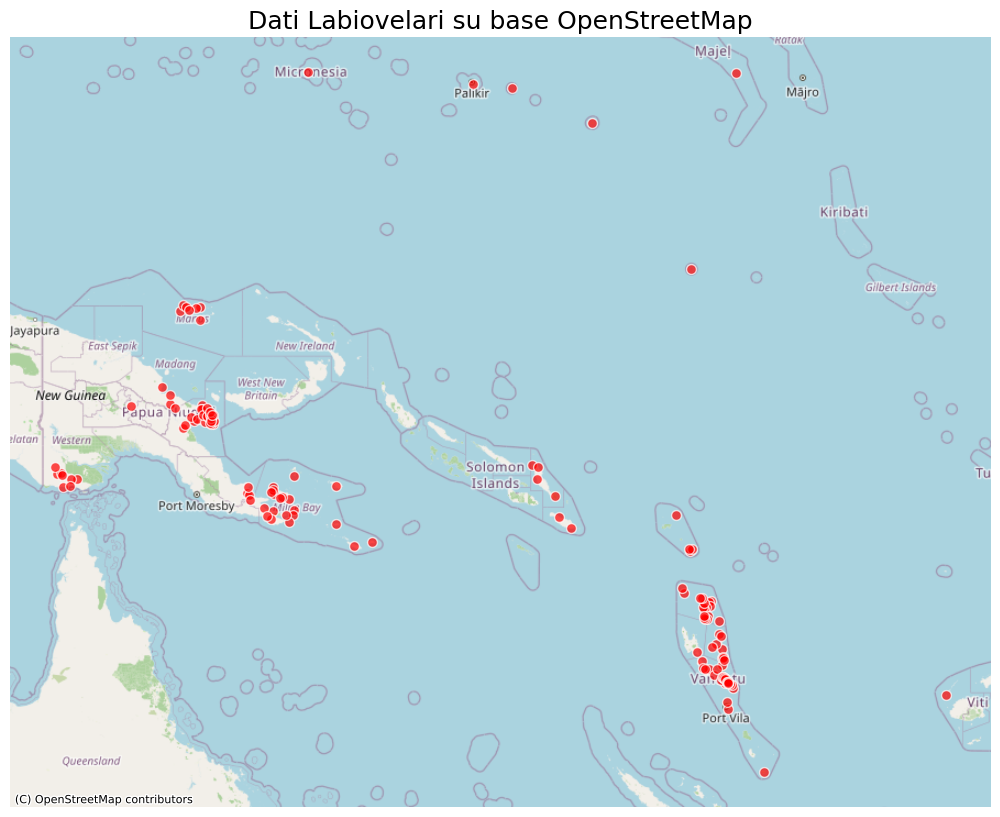

In [ ]:
import contextily as cx
import matplotlib.pyplot as plt

# 1. Pulizia e Trasformazione (fondamentale per le mappe web)
# Trasformiamo i dati da coordinate geografiche a Web Mercator
gdf_osm = gdf.dropna(subset=["geometry"]).to_crs(epsg=3857)

# 2. Creazione del plot
fig, ax = plt.subplots(figsize=(15, 10))

# 3. Disegniamo i tuoi punti
gdf_osm.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=50,
    edgecolor="white",
    alpha=0.7,
    zorder=2,
)

# 4. Aggiungiamo lo sfondo di OpenStreetMap
# Usiamo il fornitore OSM_A (standard) o altri come STAMEN_TERRAIN
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, zorder=1)

# 5. Zoom sulla Melanesia (in coordinate Web Mercator)
# Nota: le coordinate cambiano rispetto ai gradi visti prima
# Se vuoi usare i gradi, imposta lo zoom PRIMA di cx.add_basemap
ax.set_axis_off()
ax.set_title("Dati Labiovelari su base OpenStreetMap", fontsize=18)

plt.show()